# RSA COMPARE v2 — ResNet-50 / ViT-B/16 / CLIP vs. fMRI
### THINGS-fMRI Dataset, sub-01

**Wichtig:** Diese Version unterstützt Export der RDMs für das Predictive Coding Projekt.  
Workflow: Zellen 1–7 ausführen, dann optional Zelle 8 (Export) ausführen.


In [1]:
# ══════════════════════════════════════════════════════════════════
# ZELLE 0 — Test
# ══════════════════════════════════════════════════════════════════

with open(r'C:\Users\nilsl\Desktop\Projekte\predictive coding\stim_order_pc.txt') as f:
    lines = [l.strip() for l in f.readlines()]
print(f"Anzahl Stimuli: {len(lines)}")
print(f"Erste 5: {lines[:5]}")
print(f"Letzte 5: {lines[-5:]}")

Anzahl Stimuli: 100
Erste 5: ['alligator_14n.jpg', 'altar_13s.jpg', 'ashtray_14n.jpg', 'axe_14n.jpg', 'bamboo_13s.jpg']
Letzte 5: ['wallpaper_13s.jpg', 'wasp_15n.jpg', 'watch_13s.jpg', 'whip_14s.jpg', 'wig_13s.jpg']


In [2]:
# ══════════════════════════════════════════════════════════════════
# ZELLE 1 — Imports & Konfiguration
# ══════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import h5py
import torch
import torchvision.models as models
from torchvision import transforms
from torchvision.models import vit_b_16, ViT_B_16_Weights
from PIL import Image

from scipy.stats import spearmanr
from scipy.spatial.distance import pdist, squareform
from sklearn.manifold import MDS

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tqdm import tqdm
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ── Pfade ──────────────────────────────────────────────────────
RSA_DIR           = Path(r'C:\Users\nilsl\Desktop\Projekte\RSA')
PC_DIR            = Path(r'C:\Users\nilsl\Desktop\Projekte\predictive coding')
DATENSATZ_DIR     = RSA_DIR / 'Datensatz'
H5_FILE           = DATENSATZ_DIR / 'sub-01_task-things_voxel-wise-responses.h5'
VOX_META          = DATENSATZ_DIR / 'sub-01_task-things_voxel-metadata.csv'
STIM_META         = DATENSATZ_DIR / 'sub-01_task-things_stimulus-metadata.csv'
THINGS_IMAGES_DIR = DATENSATZ_DIR / 'images_THINGS' / 'object_images'

# ── Konfiguration ──────────────────────────────────────────────
N_IMAGES  = 100
DEVICE    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ROI_NAMES = ['V1', 'V2', 'V3', 'V4', 'LOC', 'IT']

# PC_DIR-Pfad für stim_order_pc.txt
STIM_ORDER_PC_PATH = PC_DIR / 'stim_order_pc.txt'

print(f'Device: {DEVICE}')
for f in [H5_FILE, VOX_META, STIM_META, THINGS_IMAGES_DIR]:
    print(f"  {'✅' if f.exists() else '❌'} {f.name}")
print(f"  {'✅' if STIM_ORDER_PC_PATH.exists() else '⚠️  nicht gefunden (erst PC-Skript ausführen)'} stim_order_pc.txt")


Device: cpu
  ✅ sub-01_task-things_voxel-wise-responses.h5
  ✅ sub-01_task-things_voxel-metadata.csv
  ✅ sub-01_task-things_stimulus-metadata.csv
  ✅ object_images
  ✅ stim_order_pc.txt


In [3]:
# ══════════════════════════════════════════════════════════════════
# ZELLE 2 — fMRI-Daten laden & stim_order festlegen
# ══════════════════════════════════════════════════════════════════
print(STIM_ORDER_PC_PATH.exists())  # muss True sein
def compute_rdm(features: np.ndarray) -> np.ndarray:
    return squareform(pdist(features, metric='correlation'))

def compare_rdms(rdm_a, rdm_b):
    n   = rdm_a.shape[0]
    idx = np.triu_indices(n, k=1)
    rho, p = spearmanr(rdm_a[idx], rdm_b[idx])
    return rho, p

# ── Metadaten ─────────────────────────────────────────────────
vox_meta  = pd.read_csv(VOX_META,  sep=',')
stim_meta = pd.read_csv(STIM_META, sep=',')
print(f'vox_meta:  {vox_meta.shape}')
print(f'stim_meta: {stim_meta.shape}')

# ── ROI-Masken ────────────────────────────────────────────────
roi_masks = {}
roi_masks['V1']  = vox_meta['V1'].values.astype(bool)
roi_masks['V2']  = vox_meta['V2'].values.astype(bool)
roi_masks['V3']  = vox_meta['V3'].values.astype(bool)
roi_masks['V4']  = vox_meta['hV4'].values.astype(bool)
roi_masks['LOC'] = (vox_meta['lLOC'].values.astype(bool) |
                    vox_meta['rLOC'].values.astype(bool))
roi_masks['IT']  = vox_meta['IT'].values.astype(bool)

for roi, mask in roi_masks.items():
    print(f'  {roi:5}: {mask.sum():,} Voxel')

combined_mask     = np.zeros(len(vox_meta), dtype=bool)
for m in roi_masks.values():
    combined_mask |= m
roi_voxel_indices = np.where(combined_mask)[0]
global_to_local   = {int(g): l for l, g in enumerate(roi_voxel_indices)}

# ── HDF5 laden ────────────────────────────────────────────────
print('\nLade fMRI...')
with h5py.File(H5_FILE, 'r') as f:
    dset         = f['ResponseData/block0_values']
    print(f'Dataset shape: {dset.shape}')
    roi_data_raw = dset[roi_voxel_indices, :].astype(np.float32)

responses_all = roi_data_raw.T
responses_all = (responses_all - responses_all.mean(axis=0)) / \
                (responses_all.std(axis=0) + 1e-8)
print(f'responses_all: {responses_all.shape}')

# ── stim_order festlegen ──────────────────────────────────────
# Priorität: stim_order_pc.txt (für validen PC-Vergleich)
# Fallback:  eigene Auswahl (erste N_IMAGES Test-Stimuli)
stim_meta_test = stim_meta[stim_meta['trial_type'] == 'test'].copy()

if STIM_ORDER_PC_PATH.exists():
    with open(STIM_ORDER_PC_PATH) as f:
        stim_order = [line.strip() for line in f.readlines()]
    print(f'\nstim_order aus PC-Skript geladen: {len(stim_order)} Stimuli ✅')
    print('(Stimuli identisch mit PC-Experiment — Vergleich valide)')
else:
    seen, stim_order = set(), []
    for s in stim_meta_test['stimulus']:
        if s not in seen:
            seen.add(s)
            stim_order.append(s)
    stim_order = stim_order[:N_IMAGES]
    print(f'\nstim_order aus fMRI-Metadaten: {len(stim_order)} Stimuli ⚠️')
    print('WARNUNG: stim_order_pc.txt nicht gefunden.')
    print('Für validen PC-Vergleich: erst PC-Skript ausführen, dann neu starten.')

# ── fMRI-Responses mitteln ────────────────────────────────────
stim_responses, category_labels = [], []
for stim in tqdm(stim_order, desc='fMRI mitteln'):
    idx = stim_meta_test.index[stim_meta_test['stimulus'] == stim].tolist()
    stim_responses.append(responses_all[idx].mean(axis=0))
    category_labels.append(stim_meta_test.loc[idx[0], 'concept'])

responses = np.array(stim_responses)
print(f'Gemittelt: {responses.shape}')

# ── fMRI-RDMs ─────────────────────────────────────────────────
fmri_rdms = {}
for roi in tqdm(ROI_NAMES, desc='fMRI RDMs'):
    g_idx = np.where(roi_masks[roi])[0]
    l_idx = np.array([global_to_local[int(g)] for g in g_idx
                      if int(g) in global_to_local])
    fmri_rdms[roi] = compute_rdm(responses[:, l_idx])

print('\nfMRI-RDMs berechnet ✅')


True
vox_meta:  (211339, 222)
stim_meta: (9840, 7)
  V1   : 1,049 Voxel
  V2   : 774 Voxel
  V3   : 762 Voxel
  V4   : 613 Voxel
  LOC  : 2,700 Voxel
  IT   : 4,145 Voxel

Lade fMRI...
Dataset shape: (211339, 9840)
responses_all: (9840, 8406)

stim_order aus PC-Skript geladen: 100 Stimuli ✅
(Stimuli identisch mit PC-Experiment — Vergleich valide)


fMRI mitteln: 100%|██████████| 100/100 [00:00<00:00, 488.57it/s]


Gemittelt: (100, 8406)


fMRI RDMs: 100%|██████████| 6/6 [00:00<00:00, 209.73it/s]


fMRI-RDMs berechnet ✅


In [4]:
# ══════════════════════════════════════════════════════════════════
# ZELLE 3 — Bilder laden
# ══════════════════════════════════════════════════════════════════

preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

image_tensors_list  = []
category_labels_cnn = []
missing = 0

for stim_name in tqdm(stim_order, desc='Bilder laden'):
    concept  = stim_name.split('_')[0]
    img_path = THINGS_IMAGES_DIR / concept / stim_name
    if img_path.exists():
        img = Image.open(img_path).convert('RGB')
    else:
        img = Image.fromarray(np.zeros((224, 224, 3), dtype=np.uint8))
        missing += 1
    image_tensors_list.append(preprocess(img))
    category_labels_cnn.append(concept)

print(f'Bilder: {len(image_tensors_list)}  fehlend: {missing}')
image_tensors = torch.stack(image_tensors_list)
print('✅ Bilder bereit')


Bilder laden: 100%|██████████| 100/100 [00:00<00:00, 113.56it/s]

Bilder: 100  fehlend: 5
✅ Bilder bereit


In [5]:
# ══════════════════════════════════════════════════════════════════
# ZELLE 4 — ResNet-50 Aktivierungen & RDMs
# ══════════════════════════════════════════════════════════════════

resnet       = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
resnet.eval().to(DEVICE)

resnet_layers   = ['layer1', 'layer2', 'layer3', 'layer4']
resnet_raw      = {}
resnet_features = {l: [] for l in resnet_layers}

def make_hook(name, store):
    def hook(module, input, output):
        store[name] = output.mean(dim=[2, 3]).detach().cpu()
    return hook

hooks = [
    resnet.layer1.register_forward_hook(make_hook('layer1', resnet_raw)),
    resnet.layer2.register_forward_hook(make_hook('layer2', resnet_raw)),
    resnet.layer3.register_forward_hook(make_hook('layer3', resnet_raw)),
    resnet.layer4.register_forward_hook(make_hook('layer4', resnet_raw)),
]

with torch.no_grad():
    for start in tqdm(range(0, len(image_tensors), 32), desc='ResNet-50'):
        batch = image_tensors[start:start+32].to(DEVICE)
        _ = resnet(batch)
        for l in resnet_layers:
            resnet_features[l].append(resnet_raw[l].numpy())

for h in hooks:
    h.remove()

for l in resnet_layers:
    resnet_features[l] = np.concatenate(resnet_features[l], axis=0)

resnet_rdms = {l: compute_rdm(resnet_features[l]) for l in resnet_layers}

print('ResNet-50 Features:')
for l in resnet_layers:
    print(f'  {l}: {resnet_features[l].shape}')
print('✅ ResNet-50 fertig')


ResNet-50: 100%|██████████| 4/4 [00:05<00:00,  1.41s/it]

ResNet-50 Features:
  layer1: (100, 256)
  layer2: (100, 512)
  layer3: (100, 1024)
  layer4: (100, 2048)
✅ ResNet-50 fertig


In [6]:
# ══════════════════════════════════════════════════════════════════
# ZELLE 5 — ViT-B/16 Aktivierungen & RDMs
# ══════════════════════════════════════════════════════════════════

vit = vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_V1)
vit.eval().to(DEVICE)

vit_layer_indices = {'block3': 2, 'block6': 5, 'block9': 8, 'block12': 11}
vit_raw           = {}
vit_features      = {k: [] for k in vit_layer_indices}

def make_vit_hook(name, store):
    def hook(module, input, output):
        store[name] = output[:, 1:, :].mean(dim=1).detach().cpu()
    return hook

vit_hooks = []
for name, idx in vit_layer_indices.items():
    h = vit.encoder.layers[idx].register_forward_hook(
        make_vit_hook(name, vit_raw))
    vit_hooks.append(h)

with torch.no_grad():
    for start in tqdm(range(0, len(image_tensors), 32), desc='ViT-B/16'):
        batch = image_tensors[start:start+32].to(DEVICE)
        _ = vit(batch)
        for name in vit_layer_indices:
            vit_features[name].append(vit_raw[name].numpy())

for h in vit_hooks:
    h.remove()

for name in vit_layer_indices:
    vit_features[name] = np.concatenate(vit_features[name], axis=0)

vit_rdms = {name: compute_rdm(vit_features[name]) for name in vit_layer_indices}

print('ViT-B/16 Features:')
for name in vit_layer_indices:
    print(f'  {name}: {vit_features[name].shape}')
print('✅ ViT-B/16 fertig')


ViT-B/16: 100%|██████████| 4/4 [00:24<00:00,  6.04s/it]

ViT-B/16 Features:
  block3: (100, 768)
  block6: (100, 768)
  block9: (100, 768)
  block12: (100, 768)
✅ ViT-B/16 fertig


In [7]:
# ══════════════════════════════════════════════════════════════════
# ZELLE 6 — CLIP Aktivierungen & RDMs
# ══════════════════════════════════════════════════════════════════

try:
    import clip
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'clip-anytorch',
                    '--quiet'], check=True)
    import clip

clip_model, clip_preprocess = clip.load('ViT-B/32', device=DEVICE)
clip_model.eval()

clip_tensors_list = []
for stim_name in tqdm(stim_order, desc='CLIP Bilder laden'):
    concept  = stim_name.split('_')[0]
    img_path = THINGS_IMAGES_DIR / concept / stim_name
    if img_path.exists():
        img = Image.open(img_path).convert('RGB')
    else:
        img = Image.fromarray(np.zeros((224, 224, 3), dtype=np.uint8))
    clip_tensors_list.append(clip_preprocess(img))

clip_tensors = torch.stack(clip_tensors_list)

clip_layer_indices = {'clip_block3': 2, 'clip_block6': 5,
                      'clip_block9': 8, 'clip_block12': 11}
clip_raw      = {}
clip_features = {k: [] for k in clip_layer_indices}

def make_clip_hook(name, store):
    def hook(module, input, output):
        if output.dim() == 3:
            store[name] = output[1:, :, :].mean(dim=0).detach().cpu()
        else:
            store[name] = output.detach().cpu()
    return hook

clip_hooks = []
for name, idx in clip_layer_indices.items():
    h = clip_model.visual.transformer.resblocks[idx].register_forward_hook(
        make_clip_hook(name, clip_raw))
    clip_hooks.append(h)

with torch.no_grad():
    for start in tqdm(range(0, len(clip_tensors), 32), desc='CLIP'):
        batch = clip_tensors[start:start+32].to(DEVICE)
        _ = clip_model.encode_image(batch)
        for name in clip_layer_indices:
            clip_features[name].append(clip_raw[name].numpy())

for h in clip_hooks:
    h.remove()

for name in clip_layer_indices:
    clip_features[name] = np.concatenate(clip_features[name], axis=0)

clip_rdms = {name: compute_rdm(clip_features[name])
             for name in clip_layer_indices}

print('CLIP Features:')
for name in clip_layer_indices:
    print(f'  {name}: {clip_features[name].shape}')
print('✅ CLIP fertig')


CLIP: 100%|██████████| 4/4 [00:04<00:00,  1.25s/it]

CLIP Features:
  clip_block3: (100, 768)
  clip_block6: (100, 768)
  clip_block9: (100, 768)
  clip_block12: (100, 768)
✅ CLIP fertig


In [8]:
# ══════════════════════════════════════════════════════════════════
# ZELLE 7 — RSA: ResNet-50 / ViT-B/16 / CLIP vs. Gehirn
# ══════════════════════════════════════════════════════════════════

n_rois           = len(ROI_NAMES)
vit_layer_names  = list(vit_layer_indices.keys())
clip_layer_names = list(clip_layer_indices.keys())

resnet_rho = np.zeros((len(resnet_layers), n_rois))
resnet_p   = np.zeros_like(resnet_rho)
vit_rho    = np.zeros((len(vit_layer_names), n_rois))
vit_p      = np.zeros_like(vit_rho)
clip_rho   = np.zeros((len(clip_layer_names), n_rois))
clip_p     = np.zeros_like(clip_rho)

for i, layer in enumerate(resnet_layers):
    for j, roi in enumerate(ROI_NAMES):
        resnet_rho[i,j], resnet_p[i,j] = compare_rdms(resnet_rdms[layer], fmri_rdms[roi])

for i, name in enumerate(vit_layer_names):
    for j, roi in enumerate(ROI_NAMES):
        vit_rho[i,j], vit_p[i,j] = compare_rdms(vit_rdms[name], fmri_rdms[roi])

for i, name in enumerate(clip_layer_names):
    for j, roi in enumerate(ROI_NAMES):
        clip_rho[i,j], clip_p[i,j] = compare_rdms(clip_rdms[name], fmri_rdms[roi])

for label, rho_mat, layer_names in [
    ('ResNet-50', resnet_rho, resnet_layers),
    ('ViT-B/16',  vit_rho,   vit_layer_names),
    ('CLIP',      clip_rho,  clip_layer_names),
]:
    print(f'{label}:')
    print(f'  {"":12}', '  '.join(f'{r:>6}' for r in ROI_NAMES))
    for i, lname in enumerate(layer_names):
        row = f'  {lname:12}'
        for j in range(n_rois):
            row += f'  {rho_mat[i,j]:+.3f}'
        print(row)
    print()
print('✅ RSA fertig')


ResNet-50:
                   V1      V2      V3      V4     LOC      IT
  layer1        +0.135  +0.113  +0.089  +0.069  +0.009  +0.017
  layer2        +0.160  +0.126  +0.099  +0.104  +0.011  +0.033
  layer3        +0.123  +0.098  +0.086  +0.121  +0.048  +0.082
  layer4        +0.080  +0.054  +0.053  +0.086  +0.116  +0.136

ViT-B/16:
                   V1      V2      V3      V4     LOC      IT
  block3        +0.201  +0.163  +0.125  +0.127  +0.026  +0.052
  block6        +0.155  +0.114  +0.096  +0.125  +0.054  +0.080
  block9        +0.099  +0.066  +0.055  +0.093  +0.064  +0.086
  block12       +0.067  +0.066  +0.044  +0.070  +0.022  +0.056

CLIP:
                   V1      V2      V3      V4     LOC      IT
  clip_block3   +0.157  +0.131  +0.108  +0.094  +0.008  +0.029
  clip_block6   +0.160  +0.121  +0.109  +0.124  +0.046  +0.085
  clip_block9   +0.146  +0.089  +0.083  +0.105  +0.083  +0.121
  clip_block12  +0.106  +0.072  +0.072  +0.053  +0.022  +0.036

✅ RSA fertig


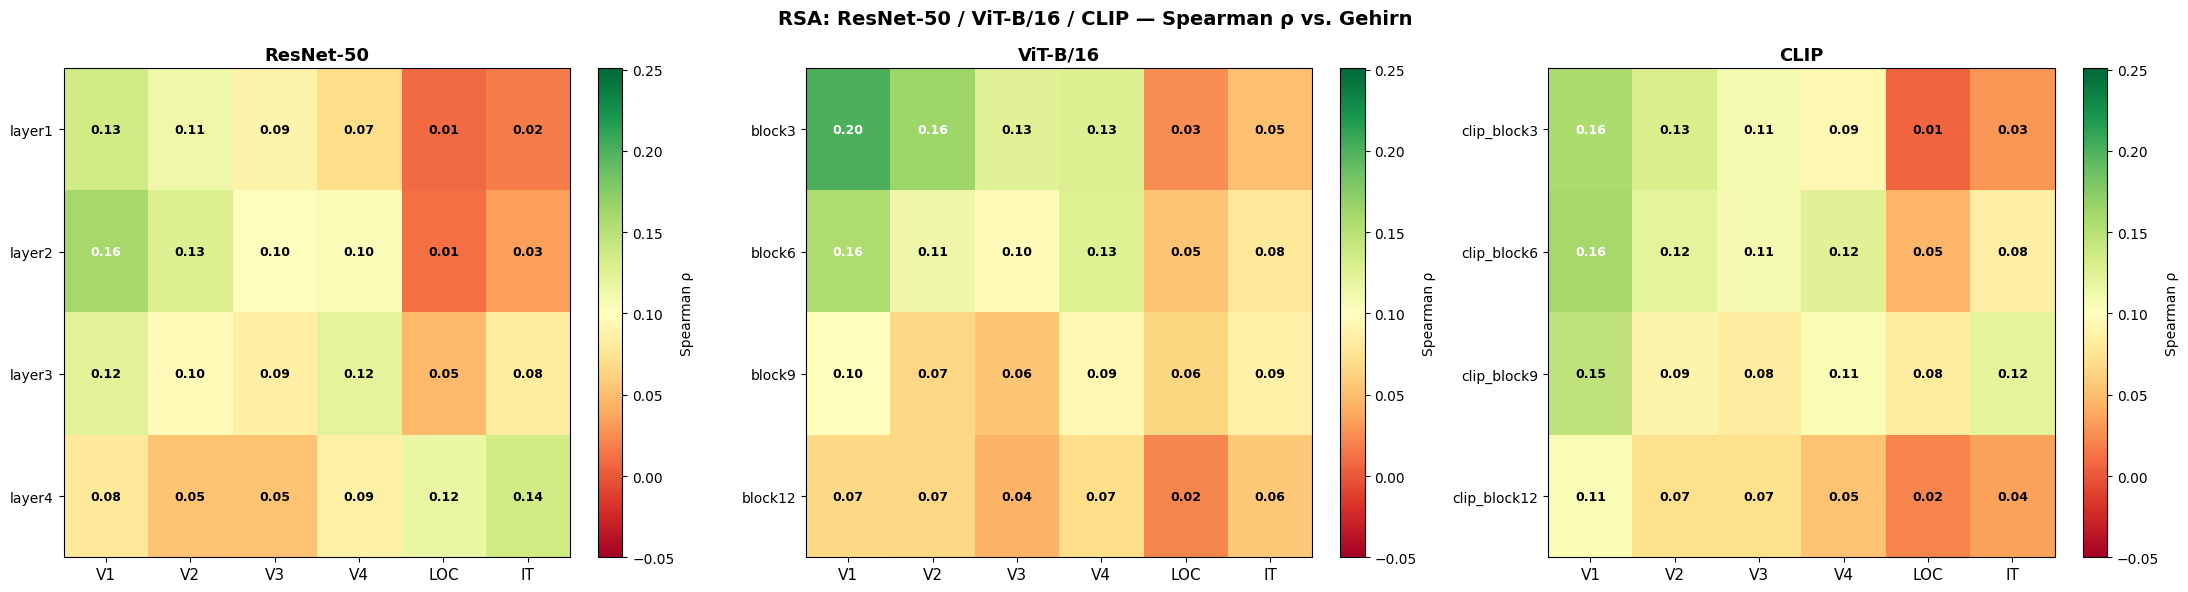

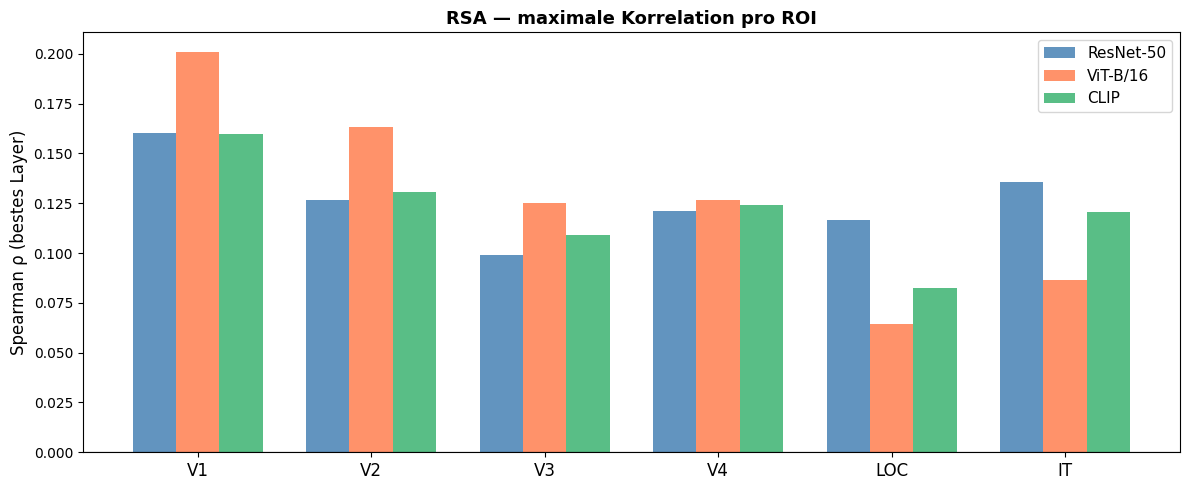

✅ Plots gespeichert


In [9]:
# ══════════════════════════════════════════════════════════════════
# ZELLE 8 — Visualisierung
# ══════════════════════════════════════════════════════════════════

vmax = max(resnet_rho.max(), vit_rho.max(), clip_rho.max()) + 0.05

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle('RSA: ResNet-50 / ViT-B/16 / CLIP — Spearman ρ vs. Gehirn',
             fontsize=14, fontweight='bold')

all_models = [
    ('ResNet-50', resnet_rho, resnet_layers),
    ('ViT-B/16',  vit_rho,   vit_layer_names),
    ('CLIP',      clip_rho,  clip_layer_names),
]

for ax, (title, rho_mat, layer_names) in zip(axes, all_models):
    im = ax.imshow(rho_mat, cmap='RdYlGn', vmin=-0.05, vmax=vmax, aspect='auto')
    ax.set_xticks(range(n_rois))
    ax.set_xticklabels(ROI_NAMES, fontsize=11)
    ax.set_yticks(range(len(layer_names)))
    ax.set_yticklabels(layer_names, fontsize=10)
    ax.set_title(title, fontsize=13, fontweight='bold')
    for i in range(len(layer_names)):
        for j in range(n_rois):
            col = 'white' if rho_mat[i,j] > vmax * 0.6 else 'black'
            ax.text(j, i, f'{rho_mat[i,j]:.2f}',
                    ha='center', va='center', fontsize=9,
                    color=col, fontweight='bold')
    plt.colorbar(im, ax=ax, label='Spearman ρ', fraction=0.046)

plt.tight_layout()
plt.savefig(RSA_DIR / 'rsa_compare_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

# Balkendiagramm
fig, ax = plt.subplots(figsize=(12, 5))
resnet_best = resnet_rho.max(axis=0)
vit_best    = vit_rho.max(axis=0)
clip_best   = clip_rho.max(axis=0)
x = np.arange(n_rois)
w = 0.25
ax.bar(x - w, resnet_best, w, label='ResNet-50', color='steelblue',       alpha=0.85)
ax.bar(x,     vit_best,    w, label='ViT-B/16',  color='coral',           alpha=0.85)
ax.bar(x + w, clip_best,   w, label='CLIP',      color='mediumseagreen',  alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(ROI_NAMES, fontsize=12)
ax.set_ylabel('Spearman ρ (bestes Layer)', fontsize=12)
ax.set_title('RSA — maximale Korrelation pro ROI', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig(RSA_DIR / 'rsa_compare_bar.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Plots gespeichert')


In [10]:
# ══════════════════════════════════════════════════════════════════
# ZELLE 9 — Noise Ceiling (Split-Half, Spearman-Brown)
# ══════════════════════════════════════════════════════════════════

def rdm_noise_ceiling(roi_key, n_splits=100):
    g_idx = np.where(roi_masks[roi_key])[0]
    l_idx = np.array([global_to_local[int(g)] for g in g_idx
                      if int(g) in global_to_local])
    rhos = []
    for _ in range(n_splits):
        half_a, half_b = [], []
        for stim in stim_order:
            idx = stim_meta_test.index[stim_meta_test['stimulus'] == stim].tolist()
            np.random.shuffle(idx)
            mid = max(1, len(idx) // 2)
            half_a.append(responses_all[idx[:mid]].mean(axis=0))
            half_b.append(responses_all[idx[mid:]].mean(axis=0))
        rdm_a = compute_rdm(np.array(half_a)[:, l_idx])
        rdm_b = compute_rdm(np.array(half_b)[:, l_idx])
        n     = rdm_a.shape[0]
        tri   = np.triu_indices(n, k=1)
        rho, _ = spearmanr(rdm_a[tri], rdm_b[tri])
        rhos.append((2 * rho) / (1 + rho))
    return np.mean(rhos)

print('Noise Ceilings:')
noise_ceilings = {}
for roi in ROI_NAMES:
    nc = rdm_noise_ceiling(roi)
    noise_ceilings[roi] = nc
    r  = resnet_rho[:, ROI_NAMES.index(roi)].max()
    v  = vit_rho[:,   ROI_NAMES.index(roi)].max()
    c  = clip_rho[:,  ROI_NAMES.index(roi)].max()
    print(f'  {roi:5}: NC={nc:.3f}  ResNet={r:.3f} ({r/nc*100:.0f}%NC)  '
          f'ViT={v:.3f} ({v/nc*100:.0f}%NC)  CLIP={c:.3f} ({c/nc*100:.0f}%NC)')
print('✅ Fertig')


Noise Ceilings:
  V1   : NC=0.519  ResNet=0.160 (31%NC)  ViT=0.201 (39%NC)  CLIP=0.160 (31%NC)
  V2   : NC=0.447  ResNet=0.126 (28%NC)  ViT=0.163 (37%NC)  CLIP=0.131 (29%NC)
  V3   : NC=0.380  ResNet=0.099 (26%NC)  ViT=0.125 (33%NC)  CLIP=0.109 (29%NC)
  V4   : NC=0.231  ResNet=0.121 (52%NC)  ViT=0.127 (55%NC)  CLIP=0.124 (54%NC)
  LOC  : NC=0.392  ResNet=0.116 (30%NC)  ViT=0.064 (16%NC)  CLIP=0.083 (21%NC)
  IT   : NC=0.405  ResNet=0.136 (33%NC)  ViT=0.086 (21%NC)  CLIP=0.121 (30%NC)
✅ Fertig


In [11]:
# ══════════════════════════════════════════════════════════════════
# ZELLE 10 — Interpretation
# ══════════════════════════════════════════════════════════════════

clip_layer_names_short = list(clip_layer_indices.keys())

print('=' * 78)
print('VERGLEICH: ResNet-50 / ViT-B/16 / CLIP')
print('=' * 78)
print(f'  {"ROI":5} {"ResNet ρ":>10} {"Layer":>8} | '
      f'{"ViT ρ":>8} {"Block":>8} | '
      f'{"CLIP ρ":>8} {"Block":>10} | {"Gewinner":>12}')
print('─' * 78)

for j, roi in enumerate(ROI_NAMES):
    r_i   = resnet_rho[:, j].argmax()
    v_i   = vit_rho[:,   j].argmax()
    c_i   = clip_rho[:,  j].argmax()
    r_rho = resnet_rho[r_i, j]
    v_rho = vit_rho[v_i, j]
    c_rho = clip_rho[c_i, j]
    best  = max([(r_rho, 'ResNet-50'), (v_rho, 'ViT-B/16'), (c_rho, 'CLIP')])[1]
    print(f'  {roi:5} {r_rho:>10.3f} {resnet_layers[r_i]:>8} | '
          f'{v_rho:>8.3f} {vit_layer_names[v_i]:>8} | '
          f'{c_rho:>8.3f} {clip_layer_names_short[c_i]:>10} | '
          f'{best:>12}')


VERGLEICH: ResNet-50 / ViT-B/16 / CLIP
  ROI     ResNet ρ    Layer |    ViT ρ    Block |   CLIP ρ      Block |     Gewinner
──────────────────────────────────────────────────────────────────────────────
  V1         0.160   layer2 |    0.201   block3 |    0.160 clip_block6 |     ViT-B/16
  V2         0.126   layer2 |    0.163   block3 |    0.131 clip_block3 |     ViT-B/16
  V3         0.099   layer2 |    0.125   block3 |    0.109 clip_block6 |     ViT-B/16
  V4         0.121   layer3 |    0.127   block3 |    0.124 clip_block6 |     ViT-B/16
  LOC        0.116   layer4 |    0.064   block9 |    0.083 clip_block9 |    ResNet-50
  IT         0.136   layer4 |    0.086   block9 |    0.121 clip_block9 |    ResNet-50


## Export für Predictive Coding Vergleich

Die folgenden Zellen exportieren ViT und CLIP RDMs für den PC-Vergleich.  
**Voraussetzung:** `stim_order_pc.txt` muss im PC-Ordner liegen (erst PC-Skript ausführen).  
**Zelle 2 muss mit stim_order_pc.txt geladen haben** — prüfe den Output von Zelle 2.


In [12]:
# ══════════════════════════════════════════════════════════════════
# ZELLE 11 — Export: ViT/CLIP RDMs für PC-Vergleich
# ══════════════════════════════════════════════════════════════════
# Voraussetzung: Zellen 1-7 müssen ausgeführt worden sein
#                UND stim_order wurde aus stim_order_pc.txt geladen

# Verifikation: stimmt stim_order mit PC überein?
if STIM_ORDER_PC_PATH.exists():
    with open(STIM_ORDER_PC_PATH) as f:
        stim_order_pc = [l.strip() for l in f.readlines()]
    if stim_order == stim_order_pc:
        print("✅ stim_order identisch mit PC-Skript — Export valide")
    else:
        overlap = len(set(stim_order) & set(stim_order_pc))
        print(f"⚠️  stim_order NICHT identisch! Überlappung: {overlap}/100")
        print("Lösung: Notebook neu starten und Zellen 1-7 neu ausführen")
        print("        (stim_order_pc.txt muss vor Zelle 2 existieren)")
else:
    print("⚠️  stim_order_pc.txt nicht gefunden — erst PC-Skript ausführen")

# ── ViT block12 exportieren (bester Layer für höhere Areale) ──
# In ZELLE 11 ersetzen:
for name in ['block3', 'block6', 'block9', 'block12']:
    rdm = compute_rdm(vit_features[name])
    np.save(PC_DIR / f'vit_rdm_{name}.npy', rdm)

# ── CLIP block12 exportieren ───────────────────────────────────
for name in ['clip_block3', 'clip_block6', 'clip_block9', 'clip_block12']:
    rdm = compute_rdm(clip_features[name])
    np.save(PC_DIR / f'clip_rdm_{name}.npy', rdm)

print("\nExport fertig ✅")
print("Nächster Schritt: PC-Skript mit VIT_RDM_PATH und CLIP_RDM_PATH ausführen")


✅ stim_order identisch mit PC-Skript — Export valide

Export fertig ✅
Nächster Schritt: PC-Skript mit VIT_RDM_PATH und CLIP_RDM_PATH ausführen
